# Prova di più modelli per la sentiment analysis

In questa parte dell'analisi vengono provati più modelli gia esistenti per provare a comprendere quali sia il miglior modello per la nostra tipologia di dati. Il lavoro si dividerà in due parti:
1. Abbiamo scaricato da kaggle un dataset con dati di reddit appositivamente per osservare il comportamento dei vari modelli, qui verranno utilizzati i modelli che come output ci diano semplicemente "sentimento positivo", "sentimento neutro" o "sentimento negativo" (attevarso una label: 1, 0 , -1)
2. Dal nostro dataset faremo un sample di 100 campioni, ad ognugno dei quali verrà assegnato un sentimento. Vogliamo in questo caso vedere se il sentimento che noi stessi percepiamo coincide con quello dei modelli (i modelli sono più forti non mi dicono pos o neg, ma gioia, rabbia, tristezza...)

In [2]:
import pandas as pd
import string
import spacy
from transformers import pipeline

/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/carlo_air_2021/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
percorso_file ='/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/kaggle_prove_modelli/Reddit_Data.csv'
file = pd.read_csv(percorso_file)

In [4]:
file.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [5]:
file.dropna(subset=['clean_comment'], inplace=True)

In [ ]:
file['clean_comment'] = file['clean_comment'].str.lower()

In [ ]:
file['clean_comment'] = file['clean_comment'].str.replace(f"[{string.punctuation}]", "", regex=True)

In [ ]:
file['clean_comment'] = file['clean_comment'].str.replace('\n', '', regex=True)

In [9]:
nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words

def preprocess_spacy(text):
    doc = nlp(text.lower()) 
    return ' '.join([token.text for token in doc if token.is_alpha and token.text not in stop_words])

file['clean_comment'] = file['clean_comment'].apply(preprocess_spacy)
print(file['clean_comment'].head(5))

0    family mormon tried explain stare puzzled time...
1    buddhism lot compatible christianity especiall...
2    seriously don thing won complex explain normal...
3    learned want teach different focus goal wrappi...
4    benefit want read living buddha living christ ...
Name: clean_comment, dtype: object


# VARI MODELLI

## Metodo 1: utilizzare modelli per percepire sentimento pos, neg o neutro

- Modello 1: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest?text=what%27s+up%3F
- Modello 2: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest?text=Good.+Fuck+AI.+It+will+destroy+jobs+and+destroy+the+climate+due+to+its+ever+ending+need+for+electricity.+We+can+advance+as+a+species+and+care+for+our+planet+without+the+need+for+AI

In [9]:
from transformers import pipeline

pipe1 = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
pipe2 = pipeline("text-classification", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")


def analizza_sentimento(pipe, text):
    try:
        result = pipe(text[:512])[0]  # limite di 512 token per sicurezza
        return result['label']
    except Exception as e:
        return None

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0
Device set to use mps:0


In [10]:
# --- 4️⃣ Applicazione dei modelli ---
file['Ris_1'] = file['clean_comment'].apply(lambda x: analizza_sentimento(pipe1, x))
file['Ris_2'] = file['clean_comment'].apply(lambda x: analizza_sentimento(pipe2, x))

# --- 5️⃣ Controllo risultati ---
print(file[['clean_comment', 'Ris_1', 'Ris_2']].head())

                                       clean_comment     Ris_1     Ris_2
0  family mormon tried explain stare puzzled time...   neutral  POSITIVE
1  buddhism lot compatible christianity especiall...   neutral  NEGATIVE
2  seriously don thing won complex explain normal...  negative  POSITIVE
3  learned want teach different focus goal wrappi...   neutral  NEGATIVE
4  benefit want read living buddha living christ ...   neutral  NEGATIVE


In [11]:
file

,clean_comment,category,Ris_1,Ris_2
0,family mormon tried explain stare puzzled time...,1,neutral,POSITIVE
1,buddhism lot compatible christianity especiall...,1,neutral,NEGATIVE
2,seriously don thing won complex explain normal...,-1,negative,POSITIVE
3,learned want teach different focus goal wrappi...,0,neutral,NEGATIVE
4,benefit want read living buddha living christ ...,1,neutral,NEGATIVE
...,...,...,...,...
37244,jesus,0,neutral,POSITIVE
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,neutral,NEGATIVE
37246,downvote karna tha par upvote hogaya,0,neutral,NEGATIVE
37247,haha nice,1,positive,POSITIVE


Vorrei che nel mio dataset la colonna Ris_1 cambiamo e poniamo: "neutral" = 0, "positive" = 1 e "negative"=-1 invece Ris_2 cambiamo e poniamo: "POSITIVE" = 1, "NEGATIVE" = -1

In [12]:
# Numero e tipo di etichette per ogni modello
print("=== Modello 1 (RoBERTa - cardiffnlp) ===")
print(file['Ris_1'].value_counts())
print("\nValori unici:", file['Ris_1'].unique())

print("\n=== Modello 2 (DistilBERT - SST-2) ===")
print(file['Ris_2'].value_counts())
print("\nValori unici:", file['Ris_2'].unique())


=== Modello 1 (RoBERTa - cardiffnlp) ===
Ris_1
neutral     22772
negative    10650
positive     3727
Name: count, dtype: int64

Valori unici: ['neutral' 'negative' 'positive']

=== Modello 2 (DistilBERT - SST-2) ===
Ris_2
NEGATIVE    25725
POSITIVE    11424
Name: count, dtype: int64

Valori unici: ['POSITIVE' 'NEGATIVE']


In [13]:
# Mappatura dei valori di Ris_1
mapping_1 = {
    'neutral': 0,
    'positive': 1,
    'negative': -1
}

# Mappatura dei valori di Ris_2
mapping_2 = {
    'POSITIVE': 1,
    'NEGATIVE': -1
}

# Applicazione delle sostituzioni
file['Ris_1'] = file['Ris_1'].replace(mapping_1)
file['Ris_2'] = file['Ris_2'].replace(mapping_2)

# Controllo finale
file.head()

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_5159/1301359812.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Ris_1'] = file['Ris_1'].replace(mapping_1)
/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_5159/1301359812.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Ris_2'] = file['Ris_2'].replace(mapping_2)


,clean_comment,category,Ris_1,Ris_2
0,family mormon tried explain stare puzzled time...,1,0,1
1,buddhism lot compatible christianity especiall...,1,0,-1
2,seriously don thing won complex explain normal...,-1,-1,1
3,learned want teach different focus goal wrappi...,0,0,-1
4,benefit want read living buddha living christ ...,1,0,-1


In [14]:
# --- 1️⃣ Percentuale di accordo su tutto il dataset ---
totale = len(file)
uguali_tot = (file['Ris_1'] == file['category']).sum()
percentuale_tot = (uguali_tot / totale) * 100

print(f"Percentuale di Ris_1 uguale a category (tutto il dataset): {percentuale_tot:.2f}%")

# --- 2️⃣ Percentuale di accordo solo per category = 1 o -1 ---
subset = file[file['category'].isin([1, -1])]
totale_sub = len(subset)
uguali_sub = (subset['Ris_1'] == subset['category']).sum()
percentuale_sub = (uguali_sub / totale_sub) * 100

print(f"Percentuale di Ris_1 uguale a category (solo category = 1 o -1): {percentuale_sub:.2f}%")

Percentuale di Ris_1 uguale a category (tutto il dataset): 49.61%
Percentuale di Ris_1 uguale a category (solo category = 1 o -1): 31.47%


## Modello 3: https://huggingface.co/ProsusAI/finbert?text=Ei+what%27s+up%3F

In [15]:
pipe3 = pipeline("text-classification", model="ProsusAI/finbert")

file['Ris_3'] = file['clean_comment'].apply(lambda x: analizza_sentimento(pipe3, x))

Device set to use mps:0


In [16]:
file.head()

,clean_comment,category,Ris_1,Ris_2,Ris_3
0,family mormon tried explain stare puzzled time...,1,0,1,neutral
1,buddhism lot compatible christianity especiall...,1,0,-1,neutral
2,seriously don thing won complex explain normal...,-1,-1,1,neutral
3,learned want teach different focus goal wrappi...,0,0,-1,neutral
4,benefit want read living buddha living christ ...,1,0,-1,neutral


In [17]:
mapping_3 = {
    'positive': 1,
    'negative': -1,
    'neutral': 0
}

file['Ris_3'] = file['Ris_3'].replace(mapping_3)

file.head()

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_5159/3980411848.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Ris_3'] = file['Ris_3'].replace(mapping_3)


,clean_comment,category,Ris_1,Ris_2,Ris_3
0,family mormon tried explain stare puzzled time...,1,0,1,0
1,buddhism lot compatible christianity especiall...,1,0,-1,0
2,seriously don thing won complex explain normal...,-1,-1,1,0
3,learned want teach different focus goal wrappi...,0,0,-1,0
4,benefit want read living buddha living christ ...,1,0,-1,0


In [18]:
uguali_tot_3 = (file['Ris_3'] == file['category']).sum()
percentuale_tot_3 = (uguali_tot_3 / totale) * 100

print(f"Percentuale di Ris_1 uguale a category (tutto il dataset): {percentuale_tot_3:.2f}%")


Percentuale di Ris_1 uguale a category (tutto il dataset): 37.12%


## Modello 4: https://huggingface.co/mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis?text=Ei+what%27s+up%3F

In [19]:
pipe4 = pipeline("text-classification", model="mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis")

file['Ris_4'] = file['clean_comment'].apply(lambda x: analizza_sentimento(pipe4, x))

Device set to use mps:0


In [20]:
file.head()

,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4
0,family mormon tried explain stare puzzled time...,1,0,1,0,neutral
1,buddhism lot compatible christianity especiall...,1,0,-1,0,neutral
2,seriously don thing won complex explain normal...,-1,-1,1,0,neutral
3,learned want teach different focus goal wrappi...,0,0,-1,0,neutral
4,benefit want read living buddha living christ ...,1,0,-1,0,negative


In [21]:
mapping_4 = {
    'positive': 1,
    'negative': -1,
    'neutral': 0
}

file['Ris_4'] = file['Ris_4'].replace(mapping_4)

file.head()

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_5159/1914727537.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Ris_4'] = file['Ris_4'].replace(mapping_4)


,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4
0,family mormon tried explain stare puzzled time...,1,0,1,0,0
1,buddhism lot compatible christianity especiall...,1,0,-1,0,0
2,seriously don thing won complex explain normal...,-1,-1,1,0,0
3,learned want teach different focus goal wrappi...,0,0,-1,0,0
4,benefit want read living buddha living christ ...,1,0,-1,0,-1


In [22]:
uguali_tot_4 = (file['Ris_4'] == file['category']).sum()
percentuale_tot_4 = (uguali_tot_4 / totale) * 100

print(f"Percentuale di Ris_1 uguale a category (tutto il dataset): {percentuale_tot_4:.2f}%")

Percentuale di Ris_1 uguale a category (tutto il dataset): 43.72%


## Modello 5: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment?text=Eii+what%27s+up%3F&library=transformers

In [23]:
pipe5 = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment")

file['Ris_5'] = file['clean_comment'].apply(lambda x: analizza_sentimento(pipe5, x))

Device set to use mps:0


In [24]:
file.head()

,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4,Ris_5
0,family mormon tried explain stare puzzled time...,1,0,1,0,0,LABEL_1
1,buddhism lot compatible christianity especiall...,1,0,-1,0,0,LABEL_1
2,seriously don thing won complex explain normal...,-1,-1,1,0,0,LABEL_0
3,learned want teach different focus goal wrappi...,0,0,-1,0,0,LABEL_1
4,benefit want read living buddha living christ ...,1,0,-1,0,-1,LABEL_1


In [25]:
mapping_5 = {
    'LABEL_2': 1,
    'LABEL_0': -1,
    'LABEL_1': 0
}

file['Ris_5'] = file['Ris_5'].replace(mapping_5)

file.head()

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_5159/172716093.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Ris_5'] = file['Ris_5'].replace(mapping_5)


,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4,Ris_5
0,family mormon tried explain stare puzzled time...,1,0,1,0,0,0
1,buddhism lot compatible christianity especiall...,1,0,-1,0,0,0
2,seriously don thing won complex explain normal...,-1,-1,1,0,0,-1
3,learned want teach different focus goal wrappi...,0,0,-1,0,0,0
4,benefit want read living buddha living christ ...,1,0,-1,0,-1,0


In [26]:
uguali_tot_5 = (file['Ris_5'] == file['category']).sum()
percentuale_tot_5 = (uguali_tot_5 / totale) * 100

print(f"Percentuale di Ris_1 uguale a category (tutto il dataset): {percentuale_tot_5:.2f}%")

Percentuale di Ris_1 uguale a category (tutto il dataset): 50.34%


## Modello 6: https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment?text=Ei+what%27s+up%3F&library=transformers

In [27]:
pipe6 = pipeline("text-classification", model="cardiffnlp/twitter-xlm-roberta-base-sentiment")
file['Ris_6'] = file['clean_comment'].apply(lambda x: analizza_sentimento(pipe6, x))

Device set to use mps:0


In [28]:
file.head()

,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4,Ris_5,Ris_6
0,family mormon tried explain stare puzzled time...,1,0,1,0,0,0,positive
1,buddhism lot compatible christianity especiall...,1,0,-1,0,0,0,neutral
2,seriously don thing won complex explain normal...,-1,-1,1,0,0,-1,negative
3,learned want teach different focus goal wrappi...,0,0,-1,0,0,0,neutral
4,benefit want read living buddha living christ ...,1,0,-1,0,-1,0,neutral


In [29]:
mapping_6 = {
    'positive': 1,
    'negative': -1,
    'neutral': 0
}

file['Ris_6'] = file['Ris_6'].replace(mapping_6)

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_5159/2472808134.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Ris_6'] = file['Ris_6'].replace(mapping_6)


In [30]:
file.head()

,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4,Ris_5,Ris_6
0,family mormon tried explain stare puzzled time...,1,0,1,0,0,0,1
1,buddhism lot compatible christianity especiall...,1,0,-1,0,0,0,0
2,seriously don thing won complex explain normal...,-1,-1,1,0,0,-1,-1
3,learned want teach different focus goal wrappi...,0,0,-1,0,0,0,0
4,benefit want read living buddha living christ ...,1,0,-1,0,-1,0,0


In [31]:
uguali_tot_6 = (file['Ris_6'] == file['category']).sum()
percentuale_tot_6 = (uguali_tot_6 / totale) * 100

print(f"Percentuale di Ris_1 uguale a category (tutto il dataset): {percentuale_tot_6:.2f}%")

Percentuale di Ris_1 uguale a category (tutto il dataset): 46.55%


## Modello 7: https://huggingface.co/akshataupadhye/finetuning-sentiment-model-reddit-data?library=transformers

In [32]:
pipe7 = pipeline("text-classification", model="akshataupadhye/finetuning-sentiment-model-reddit-data")
file['Ris_7'] = file['clean_comment'].apply(lambda x: analizza_sentimento(pipe7, x))

Device set to use mps:0


In [33]:
file.head()

,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4,Ris_5,Ris_6,Ris_7
0,family mormon tried explain stare puzzled time...,1,0,1,0,0,0,1,LABEL_2
1,buddhism lot compatible christianity especiall...,1,0,-1,0,0,0,0,LABEL_2
2,seriously don thing won complex explain normal...,-1,-1,1,0,0,-1,-1,LABEL_0
3,learned want teach different focus goal wrappi...,0,0,-1,0,0,0,0,LABEL_1
4,benefit want read living buddha living christ ...,1,0,-1,0,-1,0,0,LABEL_0


In [34]:
mapping_7 = {
    'LABEL_2': 1,
    'LABEL_0': -1,
    'LABEL_1': 0
}

file['Ris_7'] = file['Ris_7'].replace(mapping_7)

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_5159/1243799421.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Ris_7'] = file['Ris_7'].replace(mapping_7)


In [35]:
uguali_tot_7 = (file['Ris_7'] == file['category']).sum()
percentuale_tot_7 = (uguali_tot_7 / totale) * 100

print(f"Percentuale di Ris_1 uguale a category (tutto il dataset): {percentuale_tot_7:.2f}%")

Percentuale di Ris_1 uguale a category (tutto il dataset): 75.94%


## Modello 8

In [36]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from peft import PeftModel
import torch

# --- 1️⃣ Carica il modello base ---
base_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
base_model = AutoModelForSequenceClassification.from_pretrained(base_model_name)

# --- 2️⃣ Applica i pesi PEFT (Chelberta) ---
model = PeftModel.from_pretrained(base_model, "UAlbertaUAIS/Chelberta")

# --- 3️⃣ Carica il tokenizer corrispondente ---
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

# --- 4️⃣ Crea una pipeline Hugging Face ---
pipe = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# --- 5️⃣ Applica al tuo dataset ---
file.dropna(subset=['clean_comment'], inplace=True)
file['clean_comment'] = file['clean_comment'].astype(str)

file['Ris_Chelberta'] = file['clean_comment'].apply(lambda x: pipe(x[:512])[0]['label'])

print(file[['clean_comment', 'Ris_Chelberta']].head())


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


                                       clean_comment Ris_Chelberta
0  family mormon tried explain stare puzzled time...       neutral
1  buddhism lot compatible christianity especiall...       neutral
2  seriously don thing won complex explain normal...      negative
3  learned want teach different focus goal wrappi...       neutral
4  benefit want read living buddha living christ ...       neutral


In [37]:
file.head()

,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4,Ris_5,Ris_6,Ris_7,Ris_Chelberta
0,family mormon tried explain stare puzzled time...,1,0,1,0,0,0,1,1,neutral
1,buddhism lot compatible christianity especiall...,1,0,-1,0,0,0,0,1,neutral
2,seriously don thing won complex explain normal...,-1,-1,1,0,0,-1,-1,-1,negative
3,learned want teach different focus goal wrappi...,0,0,-1,0,0,0,0,0,neutral
4,benefit want read living buddha living christ ...,1,0,-1,0,-1,0,0,-1,neutral


In [38]:
mapping_8 = {
    'positive': 1,
    'negative': -1,
    'neutral': 0
}

file['Ris_Chelberta'] = file['Ris_Chelberta'].replace(mapping_8)

/var/folders/5v/4kft3jsj3m55jwb7mr5cdwyr0000gn/T/ipykernel_5159/2892962197.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Ris_Chelberta'] = file['Ris_Chelberta'].replace(mapping_8)


In [39]:
uguali_tot_8 = (file['Ris_Chelberta'] == file['category']).sum()
percentuale_tot_8 = (uguali_tot_8 / totale) * 100

print(f"Percentuale di Ris_1 uguale a category (tutto il dataset): {percentuale_tot_8:.2f}%")

Percentuale di Ris_1 uguale a category (tutto il dataset): 51.73%


## Risultati

In [40]:
print(f"Percentuali dei vari modelli sul dataset completo:")
print(f"Modello 1: {percentuale_tot:.2f}%")
print(f"Modello 2: {percentuale_sub:.2f}%")
print(f"Modello 3: {percentuale_tot_3:.2f}%")
print(f"Modello 4: {percentuale_tot_4:.2f}%")
print(f"Modello 5: {percentuale_tot_5:.2f}%")
print(f"Modello 6: {percentuale_tot_6:.2f}%")
print(f"Modello 7: {percentuale_tot_7:.2f}%")
print(f"Modello 8: {percentuale_tot_8:.2f}%")

Percentuali dei vari modelli sul dataset completo:
Modello 1: 49.61%
Modello 2: 31.47%
Modello 3: 37.12%
Modello 4: 43.72%
Modello 5: 50.34%
Modello 6: 46.55%
Modello 7: 75.94%
Modello 8: 51.73%


In [41]:
# Accuracy (in percento) dei modelli
accuracies = {
    'Ris_1': 49.61,
    'Ris_5': 50.34,
    'Ris_7': 75.94,
    'Ris_Chelberta': 51.73
}

# Normalizziamo i pesi in modo che la somma sia 1
total = sum(accuracies.values())
weights = {k: v / total for k, v in accuracies.items()}
print(weights)


{'Ris_1': 0.2179509709164397, 'Ris_5': 0.22115807046832445, 'Ris_7': 0.33362621913715845, 'Ris_Chelberta': 0.22726473947807752}


In [42]:
import numpy as np

# Calcolo della somma pesata per ogni riga
weighted_sum = np.zeros(len(file))

for col, w in weights.items():
    weighted_sum += file[col] * w

# Determinazione del sentiment finale
def decision(score):
    if score > 0.25:    # soglia positiva
        return 1
    elif score < -0.25: # soglia negativa
        return -1
    else:
        return 0

file['Final_ensemble'] = [decision(s) for s in weighted_sum]

print(file[['clean_comment', 'Final_ensemble']].head())


                                       clean_comment  Final_ensemble
0  family mormon tried explain stare puzzled time...               1
1  buddhism lot compatible christianity especiall...               1
2  seriously don thing won complex explain normal...              -1
3  learned want teach different focus goal wrappi...               0
4  benefit want read living buddha living christ ...              -1


In [43]:
accuracy_final = (file['Final_ensemble'] == file['category']).mean() * 100
print(f"Accuratezza del modello ensemble: {accuracy_final:.2f}%")

Accuratezza del modello ensemble: 64.76%


L'opzione migliore è quella di combinare insieme i modelli migliori per rendere il tutto maggiormente generalizzabile su nuovi dati e aumentare la robustezza

In [44]:
file.head()

,clean_comment,category,Ris_1,Ris_2,Ris_3,Ris_4,Ris_5,Ris_6,Ris_7,Ris_Chelberta,Final_ensemble
0,family mormon tried explain stare puzzled time...,1,0,1,0,0,0,1,1,0,1
1,buddhism lot compatible christianity especiall...,1,0,-1,0,0,0,0,1,0,1
2,seriously don thing won complex explain normal...,-1,-1,1,0,0,-1,-1,-1,-1,-1
3,learned want teach different focus goal wrappi...,0,0,-1,0,0,0,0,0,0,0
4,benefit want read living buddha living christ ...,1,0,-1,0,-1,0,0,-1,0,-1


# Secondo metodo del prof

In [3]:
percorso_file ='/Users/carlo_air_2021/Desktop/TESI/Reddit_ChatGPT/kaggle_prove_modelli/Reddit_Data.csv'
file = pd.read_csv(percorso_file)

file.dropna(subset=['clean_comment'], inplace=True)
file['clean_comment'] = file['clean_comment'].str.lower()
file['clean_comment'] = file['clean_comment'].str.replace(f"[{string.punctuation}]", "", regex=True)
file['clean_comment'] = file['clean_comment'].str.replace('\n', '', regex=True)

nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words

def preprocess_spacy(text):
    doc = nlp(text.lower()) 
    return ' '.join([token.text for token in doc if token.is_alpha and token.text not in stop_words])

file['clean_comment'] = file['clean_comment'].apply(preprocess_spacy)
print(file['clean_comment'].head(5))

0    family mormon tried explain stare puzzled time...
1    buddhism lot compatible christianity especiall...
2    seriously don thing won complex explain normal...
3    learned want teach different focus goal wrappi...
4    benefit want read living buddha living christ ...
Name: clean_comment, dtype: object


Dataset shape: (37149, 2)

Distribuzione classi:
category
-1     8277
 0    13042
 1    15830
Name: count, dtype: int64

Train set: 29719 samples
Test set: 7430 samples

Estrazione embeddings BERT...

⚠️  IMPORTANTE: Con 36801 samples questo processo richiederà:
   - CPU: circa 2-3 ore
   - GPU: circa 15-30 minuti

💡 CONSIGLIO: Salva gli embeddings per riutilizzarli!

Processing training set...
Processando 29719 testi in batch di 32...
Progress: 0/29719 (0.0%)
Progress: 1600/29719 (5.4%)
Progress: 3200/29719 (10.8%)
Progress: 4800/29719 (16.2%)
Progress: 6400/29719 (21.5%)
Progress: 8000/29719 (26.9%)
Progress: 9600/29719 (32.3%)
Progress: 11200/29719 (37.7%)
Progress: 12800/29719 (43.1%)
Progress: 14400/29719 (48.5%)
Progress: 16000/29719 (53.8%)
Progress: 17600/29719 (59.2%)
Progress: 19200/29719 (64.6%)
Progress: 20800/29719 (70.0%)
Progress: 22400/29719 (75.4%)
Progress: 24000/29719 (80.8%)
Progress: 25600/29719 (86.1%)
Progress: 27200/29719 (91.5%)
Progress: 28800/29719 (96.9%)

P

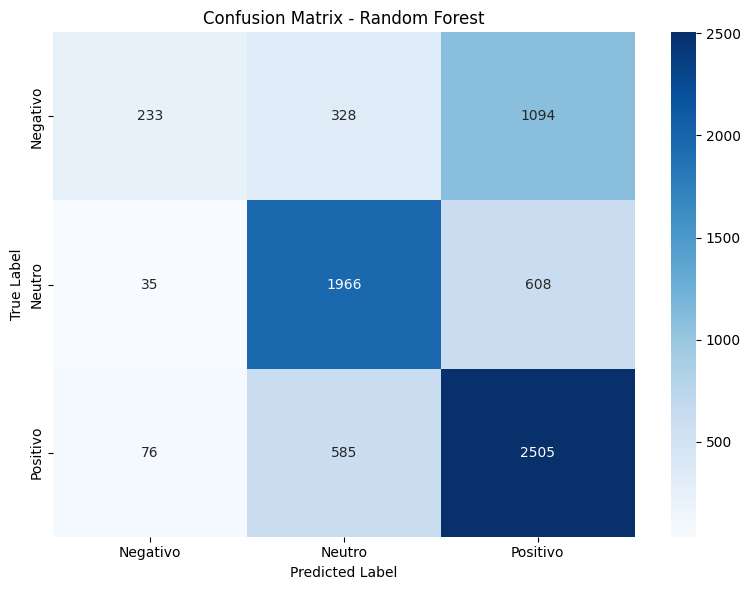


CONFRONTO ACCURACY
Random Forest            : 0.6331
SVM                      : 0.6700
Logistic Regression      : 0.6751


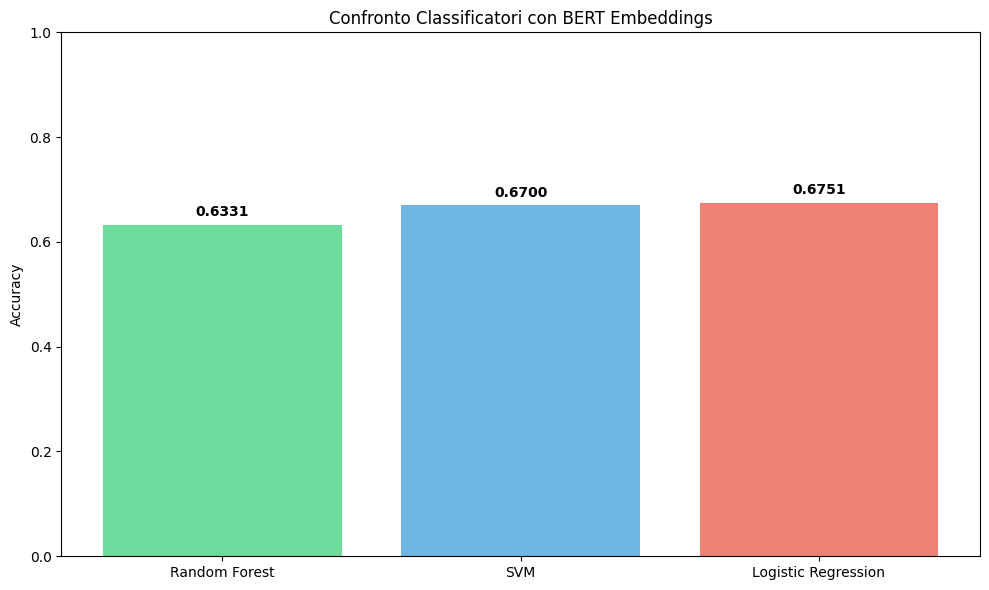


ESEMPIO PREDIZIONI
Processando 1 testi in batch di 32...
Progress: 0/1 (0.0%)

Testo: 'This product is amazing!'
Sentiment predetto: Positivo
Processando 1 testi in batch di 32...
Progress: 0/1 (0.0%)

Testo: 'It's okay, nothing special.'
Sentiment predetto: Positivo
Processando 1 testi in batch di 32...
Progress: 0/1 (0.0%)

Testo: 'Terrible experience, very disappointed.'
Sentiment predetto: Positivo


Miglior modello: Logistic Regression (Accuracy: 0.6751)
Modello salvato come 'best_classifier.pkl'


In [4]:
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertModel
import torch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. ESTRAZIONE EMBEDDINGS DA BERT
# ===============================

def get_bert_embeddings(texts, model_name='bert-base-uncased', batch_size=32):
    """
    Estrae gli embeddings BERT per una lista di testi.
    Usa il token [CLS] come rappresentazione della frase.
    
    Per 36801 samples, con batch_size=32:
    - CPU: ~2-3 ore
    - GPU: ~15-30 minuti
    """
    # Carica tokenizer e modello
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertModel.from_pretrained(model_name)
    model.eval()
    
    # Usa GPU se disponibile
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    embeddings = []
    
    # Processa in batch per efficienza
    print(f"Processando {len(texts)} testi in batch di {batch_size}...")
    for i in range(0, len(texts), batch_size):
        if i % (batch_size * 50) == 0:  # Progress ogni 50 batch
            print(f"Progress: {i}/{len(texts)} ({i/len(texts)*100:.1f}%)")
        
        batch_texts = texts[i:i+batch_size]
        
        # Tokenizza
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )
        
        # Sposta su GPU se disponibile
        encoded = {k: v.to(device) for k, v in encoded.items()}
        
        # Estrai embeddings (no gradient per efficienza)
        with torch.no_grad():
            outputs = model(**encoded)
            # Usa il token [CLS] (primo token) come rappresentazione della frase
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)
    
    # Concatena tutti i batch
    return np.vstack(embeddings)


# ===============================
# 2. CARICAMENTO DATI
# ===============================

# Assumendo che 'file' sia già caricato come DataFrame
# file = pd.read_csv('tuo_file.csv')

print("Dataset shape:", file.shape)
print("\nDistribuzione classi:")
print(file['category'].value_counts().sort_index())

# I dati sono già puliti, nessuna pulizia necessaria


# ===============================
# 3. SPLIT TRAIN/TEST
# ===============================

X_text = file['clean_comment'].tolist()
y = file['category'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {len(X_train_text)} samples")
print(f"Test set: {len(X_test_text)} samples")


# ===============================
# 4. ESTRAZIONE EMBEDDINGS
# ===============================

print("\n" + "="*50)
print("Estrazione embeddings BERT...")
print("="*50)
print("\n⚠️  IMPORTANTE: Con 36801 samples questo processo richiederà:")
print("   - CPU: circa 2-3 ore")
print("   - GPU: circa 15-30 minuti")
print("\n💡 CONSIGLIO: Salva gli embeddings per riutilizzarli!")

# Estrai embeddings per train e test
print("\nProcessing training set...")
X_train_embeddings = get_bert_embeddings(X_train_text)

print("\nProcessing test set...")
X_test_embeddings = get_bert_embeddings(X_test_text)

print(f"\n✓ Completato!")
print(f"Embeddings shape: {X_train_embeddings.shape}")
print(f"Dimensionalità embedding: {X_train_embeddings.shape[1]}")

# SALVA GLI EMBEDDINGS (così non devi ricalcolarli!)
print("\nSalvataggio embeddings...")
np.save('X_train_embeddings.npy', X_train_embeddings)
np.save('X_test_embeddings.npy', X_test_embeddings)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)
print("✓ Embeddings salvati! Prossima volta caricali con np.load()")


# ===============================
# 5. ADDESTRAMENTO CLASSIFICATORI
# ===============================

print("\n" + "="*50)
print("Addestramento classificatori...")
print("="*50)

# Dizionario per memorizzare i risultati
results = {}

# 5.1 Random Forest
print("\n1. Random Forest")
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_classifier.fit(X_train_embeddings, y_train)
y_pred_rf = rf_classifier.predict(X_test_embeddings)
acc_rf = accuracy_score(y_test, y_pred_rf)
results['Random Forest'] = acc_rf
print(f"Accuracy: {acc_rf:.4f}")

# 5.2 SVM (SVC)
print("\n2. Support Vector Machine")
svm_classifier = SVC(kernel='rbf', C=1.0, random_state=42)
svm_classifier.fit(X_train_embeddings, y_train)
y_pred_svm = svm_classifier.predict(X_test_embeddings)
acc_svm = accuracy_score(y_test, y_pred_svm)
results['SVM'] = acc_svm
print(f"Accuracy: {acc_svm:.4f}")

# 5.3 Logistic Regression
print("\n3. Logistic Regression")
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train_embeddings, y_train)
y_pred_lr = lr_classifier.predict(X_test_embeddings)
acc_lr = accuracy_score(y_test, y_pred_lr)
results['Logistic Regression'] = acc_lr
print(f"Accuracy: {acc_lr:.4f}")


# ===============================
# 6. VALUTAZIONE DETTAGLIATA
# ===============================

print("\n" + "="*50)
print("RISULTATI DETTAGLIATI - RANDOM FOREST")
print("="*50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, 
                          target_names=['Negativo (-1)', 'Neutro (0)', 'Positivo (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Neutro', 'Positivo'],
            yticklabels=['Negativo', 'Neutro', 'Positivo'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


# ===============================
# 7. CONFRONTO MODELLI
# ===============================

print("\n" + "="*50)
print("CONFRONTO ACCURACY")
print("="*50)
for model, acc in results.items():
    print(f"{model:25s}: {acc:.4f}")

# Grafico comparativo
plt.figure(figsize=(10, 6))
models = list(results.keys())
accuracies = list(results.values())
colors = ['#2ecc71', '#3498db', '#e74c3c']
plt.bar(models, accuracies, color=colors, alpha=0.7)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Confronto Classificatori con BERT Embeddings')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


# ===============================
# 8. ESEMPIO PREDIZIONE
# ===============================

def predict_sentiment(text, classifier, label_map={-1: 'Negativo', 0: 'Neutro', 1: 'Positivo'}):
    """Predice il sentiment di un nuovo testo"""
    embedding = get_bert_embeddings([text])
    prediction = classifier.predict(embedding)[0]
    return label_map[prediction]

print("\n" + "="*50)
print("ESEMPIO PREDIZIONI")
print("="*50)

test_texts = [
    "This product is amazing!",
    "It's okay, nothing special.",
    "Terrible experience, very disappointed."
]

for text in test_texts:
    sentiment = predict_sentiment(text, rf_classifier)
    print(f"\nTesto: '{text}'")
    print(f"Sentiment predetto: {sentiment}")


# ===============================
# 9. SALVATAGGIO MODELLO (opzionale)
# ===============================

import joblib

# Salva il miglior modello
best_model_name = max(results, key=results.get)
print(f"\n\nMiglior modello: {best_model_name} (Accuracy: {results[best_model_name]:.4f})")

if best_model_name == 'Random Forest':
    joblib.dump(rf_classifier, 'best_classifier.pkl')
elif best_model_name == 'SVM':
    joblib.dump(svm_classifier, 'best_classifier.pkl')
else:
    joblib.dump(lr_classifier, 'best_classifier.pkl')

print("Modello salvato come 'best_classifier.pkl'")

In [5]:
# ===============================
# 9. SALVATAGGIO MODELLO
# ===============================

import joblib

# Identifica il miglior modello
best_model_name = max(results, key=results.get)
print(f"\n\nMiglior modello: {best_model_name} (Accuracy: {results[best_model_name]:.4f})")

# Seleziona il modello corrispondente
if best_model_name == 'Random Forest':
    best_model = rf_classifier
elif best_model_name == 'SVM':
    best_model = svm_classifier
else:
    best_model = lr_classifier

# Salva il classificatore
joblib.dump(best_model, 'sentiment_classifier.pkl')
print("✓ Classificatore salvato come 'sentiment_classifier.pkl'")

# Salva i metadati
model_info = {
    'model_name': best_model_name,
    'accuracy': results[best_model_name],
    'bert_model': 'bert-base-uncased',
    'label_mapping': {-1: 'Negativo', 0: 'Neutro', 1: 'Positivo'}
}

joblib.dump(model_info, 'model_info.pkl')
print("✓ Metadati salvati come 'model_info.pkl'")



Miglior modello: Logistic Regression (Accuracy: 0.6751)
✓ Classificatore salvato come 'sentiment_classifier.pkl'
✓ Metadati salvati come 'model_info.pkl'


# ANALISI DEI VARI SENTIMENTI

In [68]:
file.head()

,clean_comment,category
0,family mormon tried explain stare puzzled time...,1
1,buddhism lot compatible christianity especiall...,1
2,seriously don thing won complex explain normal...,-1
3,learned want teach different focus goal wrappi...,0
4,benefit want read living buddha living christ ...,1


Modelli:

1. https://huggingface.co/cardiffnlp/twitter-roberta-base-emotion-latest?utm_source=chatgpt.com&text=ei
2. 
3. https://huggingface.co/michellejieli/emotion_text_classifier?text=When+we+catch+the+guy%2C+we+should+give+him+a+Congressional+Medal+of+Honor
4. https://huggingface.co/j-hartmann/emotion-english-distilroberta-base?text=Good.+Fuck+AI.+It+will+destroy+jobs+and+destroy+the+climate+due+to+its+ever+ending+need+for+electricity.+We+can+advance+as+a+species+and+care+for+our+planet+without+the+need+for+AI
5. https://huggingface.co/datasets/mrm8488/goemotions?utm_source=chatgpt.com

In [70]:
import pandas as pd
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("EMOTION DETECTION - Modello 1")
print("michellejieli/emotion_text_classifier")
print("="*60)

# 1. CARICAMENTO DEL FILE
print("\n[1/4] Caricamento del file CSV...")
df = file[['clean_comment']]
print(f"✓ File caricato: {len(df)} righe")
print(f"✓ Colonne disponibili: {list(df.columns)}")

# 2. INIZIALIZZAZIONE DEL MODELLO
print("\n[2/4] Caricamento del modello (può richiedere qualche minuto)...")
emotion_classifier = pipeline(
    "text-classification",
    model="michellejieli/emotion_text_classifier",
    top_k=None  # Restituisce tutti i punteggi
)
print("✓ Modello caricato con successo!")
print("✓ Emozioni riconosciute: sadness, joy, love, anger, fear, surprise")

# 3. PREDIZIONE DELLE EMOZIONI
print("\n[3/4] Analisi delle emozioni in corso...")
print("Questo può richiedere diversi minuti a seconda del numero di commenti...")

emotions = []
emotion_scores = []

for idx, comment in enumerate(df['clean_comment']):
    if idx % 100 == 0:  # Mostra progresso ogni 100 commenti
        print(f"  Processati: {idx}/{len(df)} commenti...")
    
    # Gestione valori nulli o vuoti
    if pd.isna(comment) or str(comment).strip() == '':
        emotions.append('unknown')
        emotion_scores.append(0.0)
        continue
    
    # Predizione
    try:
        result = emotion_classifier(str(comment)[:512])  # Limita a 512 caratteri
        # Prende l'emozione con lo score più alto
        top_emotion = max(result[0], key=lambda x: x['score'])
        emotions.append(top_emotion['label'])
        emotion_scores.append(round(top_emotion['score'], 4))
    except Exception as e:
        print(f"  Errore al commento {idx}: {e}")
        emotions.append('error')
        emotion_scores.append(0.0)

print(f"✓ Analisi completata: {len(df)} commenti processati")

# 4. CREAZIONE NUOVE COLONNE E SALVATAGGIO
print("\n[4/4] Creazione nuove colonne e salvataggio...")
df['emotion_model1'] = emotions
df['emotion_model1_score'] = emotion_scores

# Salva il file con le nuove colonne
output_filename = 'file_with_emotion_model1.csv'
df.to_csv(output_filename, index=False)
print(f"✓ File salvato come: {output_filename}")

# 5. STATISTICHE
print("\n" + "="*60)
print("STATISTICHE DELLE EMOZIONI RILEVATE")
print("="*60)
print("\nDistribuzione delle emozioni:")
print(df['emotion_model1'].value_counts())

print("\nScore medio per emozione:")
emotion_stats = df.groupby('emotion_model1')['emotion_model1_score'].agg(['mean', 'count'])
print(emotion_stats)

print("\n" + "="*60)
print("COMPLETATO! ✓")
print("="*60)
print(f"\nIl file '{output_filename}' contiene ora:")
print("  - emotion_model1: emozione predetta")
print("  - emotion_model1_score: confidenza della predizione (0-1)")
print("\nPuoi procedere con il modello 2!")

EMOTION DETECTION - Modello 1
michellejieli/emotion_text_classifier

[1/4] Caricamento del file CSV...
✓ File caricato: 37149 righe
✓ Colonne disponibili: ['clean_comment']

[2/4] Caricamento del modello (può richiedere qualche minuto)...


Device set to use mps:0


✓ Modello caricato con successo!
✓ Emozioni riconosciute: sadness, joy, love, anger, fear, surprise

[3/4] Analisi delle emozioni in corso...
Questo può richiedere diversi minuti a seconda del numero di commenti...
  Processati: 0/37149 commenti...
  Processati: 100/37149 commenti...
  Processati: 200/37149 commenti...
  Processati: 300/37149 commenti...
  Processati: 400/37149 commenti...
  Processati: 500/37149 commenti...
  Processati: 600/37149 commenti...
  Processati: 700/37149 commenti...
  Processati: 800/37149 commenti...
  Processati: 900/37149 commenti...
  Processati: 1000/37149 commenti...
  Processati: 1100/37149 commenti...
  Processati: 1200/37149 commenti...
  Processati: 1300/37149 commenti...
  Processati: 1400/37149 commenti...
  Processati: 1500/37149 commenti...
  Processati: 1600/37149 commenti...
  Processati: 1700/37149 commenti...
  Processati: 1800/37149 commenti...
  Processati: 1900/37149 commenti...
  Processati: 2000/37149 commenti...
  Processati: 2100/3

In [71]:
df.head()

,clean_comment,emotion_model1,emotion_model1_score
0,family mormon tried explain stare puzzled time...,neutral,0.8412
1,buddhism lot compatible christianity especiall...,joy,0.9311
2,seriously don thing won complex explain normal...,neutral,0.8544
3,learned want teach different focus goal wrappi...,neutral,0.9579
4,benefit want read living buddha living christ ...,joy,0.8676


In [72]:
import pandas as pd
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("EMOTION DETECTION - Modello 2")
print("j-hartmann/emotion-english-distilroberta-base")
print("="*60)

# 1. CARICAMENTO DEL FILE
print("\n[1/4] Caricamento del file CSV...")
# Usa il file con le emozioni del modello 1
df = pd.read_csv('file_with_emotion_model1.csv')
print(f"✓ File caricato: {len(df)} righe")
print(f"✓ Colonne disponibili: {list(df.columns)}")

# 2. INIZIALIZZAZIONE DEL MODELLO
print("\n[2/4] Caricamento del modello (può richiedere qualche minuto)...")
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None  # Restituisce tutti i punteggi
)
print("✓ Modello caricato con successo!")
print("✓ Emozioni riconosciute: anger, disgust, fear, joy, neutral, sadness, surprise")

# 3. PREDIZIONE DELLE EMOZIONI
print("\n[3/4] Analisi delle emozioni in corso...")
print("Questo può richiedere diversi minuti a seconda del numero di commenti...")

emotions = []
emotion_scores = []

for idx, comment in enumerate(df['clean_comment']):
    if idx % 100 == 0:  # Mostra progresso ogni 100 commenti
        print(f"  Processati: {idx}/{len(df)} commenti...")
    
    # Gestione valori nulli o vuoti
    if pd.isna(comment) or str(comment).strip() == '':
        emotions.append('unknown')
        emotion_scores.append(0.0)
        continue
    
    # Predizione
    try:
        result = emotion_classifier(str(comment)[:512])  # Limita a 512 caratteri
        # Prende l'emozione con lo score più alto
        top_emotion = max(result[0], key=lambda x: x['score'])
        emotions.append(top_emotion['label'])
        emotion_scores.append(round(top_emotion['score'], 4))
    except Exception as e:
        print(f"  Errore al commento {idx}: {e}")
        emotions.append('error')
        emotion_scores.append(0.0)

print(f"✓ Analisi completata: {len(df)} commenti processati")

# 4. CREAZIONE NUOVE COLONNE E SALVATAGGIO
print("\n[4/4] Creazione nuove colonne e salvataggio...")
df['emotion_model2'] = emotions
df['emotion_model2_score'] = emotion_scores

# Salva il file con le nuove colonne
output_filename = 'file_with_emotion_model2.csv'
df.to_csv(output_filename, index=False)
print(f"✓ File salvato come: {output_filename}")

# 5. STATISTICHE
print("\n" + "="*60)
print("STATISTICHE DELLE EMOZIONI RILEVATE - MODELLO 2")
print("="*60)
print("\nDistribuzione delle emozioni:")
print(df['emotion_model2'].value_counts())

print("\nScore medio per emozione:")
emotion_stats = df.groupby('emotion_model2')['emotion_model2_score'].agg(['mean', 'count'])
print(emotion_stats)

# 6. CONFRONTO TRA MODELLO 1 E MODELLO 2
print("\n" + "="*60)
print("CONFRONTO TRA MODELLO 1 E MODELLO 2")
print("="*60)

if 'emotion_model1' in df.columns:
    print("\nTabella di contingenza (quante volte i due modelli concordano):")
    contingency = pd.crosstab(df['emotion_model1'], df['emotion_model2'], margins=True)
    print(contingency)
    
    # Calcola accordo
    agreement = (df['emotion_model1'] == df['emotion_model2']).sum()
    total = len(df)
    agreement_pct = (agreement / total) * 100
    print(f"\n✓ Accordo tra i due modelli: {agreement}/{total} ({agreement_pct:.2f}%)")

print("\n" + "="*60)
print("COMPLETATO! ✓")
print("="*60)
print(f"\nIl file '{output_filename}' contiene ora:")
print("  - emotion_model1 e emotion_model1_score (dal modello precedente)")
print("  - emotion_model2 e emotion_model2_score (nuovo!)")
print("\nPuoi procedere con il modello 3!")

EMOTION DETECTION - Modello 2
j-hartmann/emotion-english-distilroberta-base

[1/4] Caricamento del file CSV...
✓ File caricato: 37149 righe
✓ Colonne disponibili: ['clean_comment', 'emotion_model1', 'emotion_model1_score']

[2/4] Caricamento del modello (può richiedere qualche minuto)...


Device set to use mps:0


✓ Modello caricato con successo!
✓ Emozioni riconosciute: anger, disgust, fear, joy, neutral, sadness, surprise

[3/4] Analisi delle emozioni in corso...
Questo può richiedere diversi minuti a seconda del numero di commenti...
  Processati: 0/37149 commenti...
  Processati: 100/37149 commenti...
  Processati: 200/37149 commenti...
  Processati: 300/37149 commenti...
  Processati: 400/37149 commenti...
  Processati: 500/37149 commenti...
  Processati: 600/37149 commenti...
  Processati: 700/37149 commenti...
  Processati: 800/37149 commenti...
  Processati: 900/37149 commenti...
  Processati: 1000/37149 commenti...
  Processati: 1100/37149 commenti...
  Processati: 1200/37149 commenti...
  Processati: 1300/37149 commenti...
  Processati: 1400/37149 commenti...
  Processati: 1500/37149 commenti...
  Processati: 1600/37149 commenti...
  Processati: 1700/37149 commenti...
  Processati: 1800/37149 commenti...
  Processati: 1900/37149 commenti...
  Processati: 2000/37149 commenti...
  Proces

In [73]:
df.head()

,clean_comment,emotion_model1,emotion_model1_score,emotion_model2,emotion_model2_score
0,family mormon tried explain stare puzzled time...,neutral,0.8412,surprise,0.5050
1,buddhism lot compatible christianity especiall...,joy,0.9311,joy,0.6214
2,seriously don thing won complex explain normal...,neutral,0.8544,surprise,0.4563
3,learned want teach different focus goal wrappi...,neutral,0.9579,neutral,0.8098
4,benefit want read living buddha living christ ...,joy,0.8676,surprise,0.9270


In [74]:
import pandas as pd
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("EMOTION DETECTION - Modello 3")
print("SamLowe/roberta-base-go_emotions")
print("ADDESTRATO SU REDDIT COMMENTS! 🎯")
print("="*60)

# 1. CARICAMENTO DEL FILE
print("\n[1/4] Caricamento del file CSV...")
# Usa il file con le emozioni dei modelli 1 e 2
df = pd.read_csv('file_with_emotion_model2.csv')
print(f"✓ File caricato: {len(df)} righe")
print(f"✓ Colonne disponibili: {list(df.columns)}")

# 2. INIZIALIZZAZIONE DEL MODELLO
print("\n[2/4] Caricamento del modello (può richiedere qualche minuto)...")
emotion_classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None  # Restituisce tutti i punteggi
)
print("✓ Modello caricato con successo!")
print("✓ Questo modello riconosce 28 emozioni diverse:")
print("   admiration, amusement, anger, annoyance, approval, caring,")
print("   confusion, curiosity, desire, disappointment, disapproval,")
print("   disgust, embarrassment, excitement, fear, gratitude, grief,")
print("   joy, love, nervousness, optimism, pride, realization, relief,")
print("   remorse, sadness, surprise, neutral")

# 3. PREDIZIONE DELLE EMOZIONI
print("\n[3/4] Analisi delle emozioni in corso...")
print("Questo può richiedere diversi minuti a seconda del numero di commenti...")

emotions = []
emotion_scores = []

for idx, comment in enumerate(df['clean_comment']):
    if idx % 100 == 0:  # Mostra progresso ogni 100 commenti
        print(f"  Processati: {idx}/{len(df)} commenti...")
    
    # Gestione valori nulli o vuoti
    if pd.isna(comment) or str(comment).strip() == '':
        emotions.append('unknown')
        emotion_scores.append(0.0)
        continue
    
    # Predizione
    try:
        result = emotion_classifier(str(comment)[:512])  # Limita a 512 caratteri
        # Prende l'emozione con lo score più alto
        top_emotion = max(result[0], key=lambda x: x['score'])
        emotions.append(top_emotion['label'])
        emotion_scores.append(round(top_emotion['score'], 4))
    except Exception as e:
        print(f"  Errore al commento {idx}: {e}")
        emotions.append('error')
        emotion_scores.append(0.0)

print(f"✓ Analisi completata: {len(df)} commenti processati")

# 4. CREAZIONE NUOVE COLONNE E SALVATAGGIO
print("\n[4/4] Creazione nuove colonne e salvataggio...")
df['emotion_model3'] = emotions
df['emotion_model3_score'] = emotion_scores

# Salva il file finale con tutti e 3 i modelli
output_filename = 'file_with_all_emotions.csv'
df.to_csv(output_filename, index=False)
print(f"✓ File salvato come: {output_filename}")

# 5. STATISTICHE DETTAGLIATE
print("\n" + "="*60)
print("STATISTICHE DELLE EMOZIONI RILEVATE - MODELLO 3")
print("="*60)
print("\nDistribuzione delle emozioni (Top 10):")
top_emotions = df['emotion_model3'].value_counts().head(10)
print(top_emotions)

print("\nScore medio per emozione (Top 10 più frequenti):")
top_emotion_names = df['emotion_model3'].value_counts().head(10).index
emotion_stats = df[df['emotion_model3'].isin(top_emotion_names)].groupby('emotion_model3')['emotion_model3_score'].agg(['mean', 'count'])
print(emotion_stats.sort_values('count', ascending=False))

# 6. ANALISI COMPARATIVA TRA I 3 MODELLI
print("\n" + "="*60)
print("ANALISI COMPARATIVA TRA I 3 MODELLI")
print("="*60)

if 'emotion_model1' in df.columns and 'emotion_model2' in df.columns:
    print("\n📊 Distribuzione delle emozioni per modello:")
    print(f"\nModello 1 (6 emozioni) - Top 5:")
    print(df['emotion_model1'].value_counts().head(5))
    
    print(f"\nModello 2 (7 emozioni) - Top 5:")
    print(df['emotion_model2'].value_counts().head(5))
    
    print(f"\nModello 3 (28 emozioni) - Top 5:")
    print(df['emotion_model3'].value_counts().head(5))
    
    # Score medi
    print("\n📈 Score medio di confidenza per modello:")
    print(f"Modello 1: {df['emotion_model1_score'].mean():.4f}")
    print(f"Modello 2: {df['emotion_model2_score'].mean():.4f}")
    print(f"Modello 3: {df['emotion_model3_score'].mean():.4f}")

# 7. DISTRIBUZIONE COMPLETA MODELLO 3
print("\n" + "="*60)
print("DISTRIBUZIONE COMPLETA DELLE 28 EMOZIONI - MODELLO 3")
print("="*60)
print(df['emotion_model3'].value_counts())

print("\n" + "="*60)
print("COMPLETATO! ✓✓✓")
print("="*60)
print(f"\nIl file finale '{output_filename}' contiene:")
print("  ✓ emotion_model1 + emotion_model1_score (6 emozioni)")
print("  ✓ emotion_model2 + emotion_model2_score (7 emozioni)")
print("  ✓ emotion_model3 + emotion_model3_score (28 emozioni - Reddit!)")
print("\nHai completato l'analisi con tutti e 3 i modelli! 🎉")
print("\nProssimi passi possibili:")
print("  - Creare un ensemble delle 3 predizioni")
print("  - Analizzare le discrepanze tra i modelli")
print("  - Visualizzare le distribuzioni delle emozioni")

EMOTION DETECTION - Modello 3
SamLowe/roberta-base-go_emotions
ADDESTRATO SU REDDIT COMMENTS! 🎯

[1/4] Caricamento del file CSV...
✓ File caricato: 37149 righe
✓ Colonne disponibili: ['clean_comment', 'emotion_model1', 'emotion_model1_score', 'emotion_model2', 'emotion_model2_score']

[2/4] Caricamento del modello (può richiedere qualche minuto)...


Device set to use mps:0


✓ Modello caricato con successo!
✓ Questo modello riconosce 28 emozioni diverse:
   admiration, amusement, anger, annoyance, approval, caring,
   confusion, curiosity, desire, disappointment, disapproval,
   disgust, embarrassment, excitement, fear, gratitude, grief,
   joy, love, nervousness, optimism, pride, realization, relief,
   remorse, sadness, surprise, neutral

[3/4] Analisi delle emozioni in corso...
Questo può richiedere diversi minuti a seconda del numero di commenti...
  Processati: 0/37149 commenti...
  Processati: 100/37149 commenti...
  Processati: 200/37149 commenti...
  Processati: 300/37149 commenti...
  Processati: 400/37149 commenti...
  Processati: 500/37149 commenti...
  Processati: 600/37149 commenti...
  Processati: 700/37149 commenti...
  Processati: 800/37149 commenti...
  Processati: 900/37149 commenti...
  Processati: 1000/37149 commenti...
  Processati: 1100/37149 commenti...
  Processati: 1200/37149 commenti...
  Processati: 1300/37149 commenti...
  Proce

In [76]:
df.head()

,clean_comment,emotion_model1,emotion_model1_score,emotion_model2,emotion_model2_score,emotion_model3,emotion_model3_score
0,family mormon tried explain stare puzzled time...,neutral,0.8412,surprise,0.5050,admiration,0.7654
1,buddhism lot compatible christianity especiall...,joy,0.9311,joy,0.6214,neutral,0.9259
2,seriously don thing won complex explain normal...,neutral,0.8544,surprise,0.4563,neutral,0.8413
3,learned want teach different focus goal wrappi...,neutral,0.9579,neutral,0.8098,neutral,0.6448
4,benefit want read living buddha living christ ...,joy,0.8676,surprise,0.9270,neutral,0.6889


In [77]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("EMOTION ENSEMBLE - Modello 2 + Modello 3")
print("Mappatura 28→7 emozioni + Ensemble finale")
print("="*60)

# 1. CARICAMENTO DEL FILE
print("\n[1/4] Caricamento del file con tutte le emozioni...")
df = pd.read_csv('file_with_all_emotions.csv')
print(f"✓ File caricato: {len(df)} righe")

# 2. MAPPATURA 28 EMOZIONI → 7 EMOZIONI
print("\n[2/4] Mappatura delle 28 emozioni del Modello 3 → 7 emozioni...")

# Dizionario di mappatura
emotion_mapping = {
    # JOY (emozioni positive/felici)
    'amusement': 'joy',
    'joy': 'joy',
    'excitement': 'joy',
    'love': 'joy',
    'optimism': 'joy',
    'pride': 'joy',
    'relief': 'joy',
    
    # SADNESS (emozioni tristi)
    'sadness': 'sadness',
    'grief': 'sadness',
    'disappointment': 'sadness',
    'remorse': 'sadness',
    
    # ANGER (rabbia/irritazione)
    'anger': 'anger',
    'annoyance': 'anger',
    'disapproval': 'anger',
    
    # FEAR (paura/ansia)
    'fear': 'fear',
    'nervousness': 'fear',
    
    # DISGUST (disgusto/imbarazzo)
    'disgust': 'disgust',
    'embarrassment': 'disgust',
    
    # SURPRISE (sorpresa/realizzazione)
    'surprise': 'surprise',
    'realization': 'surprise',
    'confusion': 'surprise',
    
    # NEUTRAL (neutro/ambiguo)
    'neutral': 'neutral',
    'approval': 'neutral',
    'admiration': 'neutral',
    'caring': 'neutral',
    'curiosity': 'neutral',
    'desire': 'neutral',
    'gratitude': 'neutral',
    
    # Gestione errori
    'unknown': 'neutral',
    'error': 'neutral'
}

# Applica la mappatura
df['emotion_model3_mapped'] = df['emotion_model3'].map(emotion_mapping)

print("✓ Mappatura completata!")
print("\nDistribuzione dopo la mappatura (Modello 3 → 7 emozioni):")
print(df['emotion_model3_mapped'].value_counts())

# 3. CREAZIONE DELL'ENSEMBLE
print("\n[3/4] Creazione dell'ensemble tra Modello 2 e Modello 3...")

# Metodo: Voting con peso sui punteggi di confidenza
ensemble_emotions = []
ensemble_scores = []
ensemble_methods = []

for idx, row in df.iterrows():
    if idx % 100 == 0:
        print(f"  Processati: {idx}/{len(df)} commenti...")
    
    emotion_m2 = row['emotion_model2']
    score_m2 = row['emotion_model2_score']
    
    emotion_m3 = row['emotion_model3_mapped']
    score_m3 = row['emotion_model3_score']
    
    # Se le emozioni coincidono, usa quella (con score medio)
    if emotion_m2 == emotion_m3:
        ensemble_emotions.append(emotion_m2)
        ensemble_scores.append(round((score_m2 + score_m3) / 2, 4))
        ensemble_methods.append('agreement')
    
    # Se non coincidono, scegli quella con score più alto
    else:
        if score_m2 >= score_m3:
            ensemble_emotions.append(emotion_m2)
            ensemble_scores.append(round(score_m2, 4))
            ensemble_methods.append('model2_higher')
        else:
            ensemble_emotions.append(emotion_m3)
            ensemble_scores.append(round(score_m3, 4))
            ensemble_methods.append('model3_higher')

# Aggiungi le nuove colonne
df['emotion_ensemble'] = ensemble_emotions
df['emotion_ensemble_score'] = ensemble_scores
df['ensemble_method'] = ensemble_methods

print("✓ Ensemble creato!")

# 4. SALVATAGGIO
print("\n[4/4] Salvataggio del file finale...")
output_filename = 'file_with_emotion_ensemble.csv'
df.to_csv(output_filename, index=False)
print(f"✓ File salvato come: {output_filename}")

# 5. STATISTICHE DETTAGLIATE
print("\n" + "="*60)
print("STATISTICHE DELL'ENSEMBLE FINALE")
print("="*60)

print("\n📊 Distribuzione delle emozioni nell'ensemble:")
print(df['emotion_ensemble'].value_counts())

print("\n📈 Score medio per emozione nell'ensemble:")
ensemble_stats = df.groupby('emotion_ensemble')['emotion_ensemble_score'].agg(['mean', 'count'])
print(ensemble_stats.sort_values('count', ascending=False))

print("\n🤝 Analisi dell'accordo tra i modelli:")
method_counts = df['ensemble_method'].value_counts()
print(method_counts)
agreement_pct = (method_counts.get('agreement', 0) / len(df)) * 100
print(f"\n✓ I due modelli sono d'accordo: {method_counts.get('agreement', 0)}/{len(df)} volte ({agreement_pct:.2f}%)")

# 6. CONFRONTO TRA TUTTI I MODELLI
print("\n" + "="*60)
print("CONFRONTO TRA TUTTE LE PREDIZIONI")
print("="*60)

print("\nModello 1 (6 emozioni originali) - Top 5:")
print(df['emotion_model1'].value_counts().head(5))

print("\nModello 2 (7 emozioni) - Top 5:")
print(df['emotion_model2'].value_counts().head(5))

print("\nModello 3 mappato (7 emozioni) - Top 5:")
print(df['emotion_model3_mapped'].value_counts().head(5))

print("\nEnsemble finale (7 emozioni) - Top 5:")
print(df['emotion_ensemble'].value_counts().head(5))

# 7. MATRICE DI CONFUSIONE tra Modello 2 e Modello 3 mappato
print("\n" + "="*60)
print("MATRICE DI CONFUSIONE: Modello 2 vs Modello 3 (mappato)")
print("="*60)
confusion_matrix = pd.crosstab(df['emotion_model2'], df['emotion_model3_mapped'], margins=True)
print(confusion_matrix)

print("\n" + "="*60)
print("COMPLETATO! 🎉")
print("="*60)
print(f"\nIl file finale '{output_filename}' contiene:")
print("  ✓ Tutte le colonne precedenti (modello 1, 2, 3)")
print("  ✓ emotion_model3_mapped: Modello 3 ridotto a 7 emozioni")
print("  ✓ emotion_ensemble: PREDIZIONE FINALE (7 emozioni)")
print("  ✓ emotion_ensemble_score: Score di confidenza")
print("  ✓ ensemble_method: Come è stata decisa la predizione")
print("\n🎯 Usa 'emotion_ensemble' come tua variabile finale!")
print("\nLe 7 emozioni finali sono:")
print("  anger, disgust, fear, joy, neutral, sadness, surprise")

EMOTION ENSEMBLE - Modello 2 + Modello 3
Mappatura 28→7 emozioni + Ensemble finale

[1/4] Caricamento del file con tutte le emozioni...
✓ File caricato: 37149 righe

[2/4] Mappatura delle 28 emozioni del Modello 3 → 7 emozioni...
✓ Mappatura completata!

Distribuzione dopo la mappatura (Modello 3 → 7 emozioni):
emotion_model3_mapped
neutral     31821
anger        1915
joy          1896
sadness       743
surprise      415
disgust       224
fear          135
Name: count, dtype: int64

[3/4] Creazione dell'ensemble tra Modello 2 e Modello 3...
  Processati: 0/37149 commenti...
  Processati: 100/37149 commenti...
  Processati: 200/37149 commenti...
  Processati: 300/37149 commenti...
  Processati: 400/37149 commenti...
  Processati: 500/37149 commenti...
  Processati: 600/37149 commenti...
  Processati: 700/37149 commenti...
  Processati: 800/37149 commenti...
  Processati: 900/37149 commenti...
  Processati: 1000/37149 commenti...
  Processati: 1100/37149 commenti...
  Processati: 1200/37

In [78]:
df.head()

,clean_comment,emotion_model1,emotion_model1_score,emotion_model2,emotion_model2_score,emotion_model3,emotion_model3_score,emotion_model3_mapped,emotion_ensemble,emotion_ensemble_score,ensemble_method
0,family mormon tried explain stare puzzled time...,neutral,0.8412,surprise,0.5050,admiration,0.7654,neutral,neutral,0.7654,model3_higher
1,buddhism lot compatible christianity especiall...,joy,0.9311,joy,0.6214,neutral,0.9259,neutral,neutral,0.9259,model3_higher
2,seriously don thing won complex explain normal...,neutral,0.8544,surprise,0.4563,neutral,0.8413,neutral,neutral,0.8413,model3_higher
3,learned want teach different focus goal wrappi...,neutral,0.9579,neutral,0.8098,neutral,0.6448,neutral,neutral,0.7273,agreement
4,benefit want read living buddha living christ ...,joy,0.8676,surprise,0.9270,neutral,0.6889,neutral,surprise,0.9270,model2_higher
